In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

In [ ]:
import torch
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from torchvision import transforms

## Utils


In [ ]:
def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5 # mean and standard deviation
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im

def make_grid(images, size=64):
    """Given a list of PIL images, stak them together for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))


In [4]:
dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")
dataset

Repo card metadata block was not found. Setting CardData to empty.
Generating train split: 100%|██████████| 1000/1000 [00:01<00:00, 887.79 examples/s]


Dataset({
    features: ['image_url', 'image_alt', 'id', 'name', 'scientific_name', 'gender', 'taxonomy', 'region', 'locality', 'date', 'usnm_no', 'guid', 'edan_url', 'source', 'stage', 'image', 'image_hash', 'sim_score'],
    num_rows: 1000
})

In [5]:
dataset[0]

{'image_url': 'https://ids.si.edu/ids/deliveryService?id=ark:/65665/m3b302800a43ef46b8a7a87a7b1eb06ab6',
 'image_alt': 'view Paper Kite digital asset number 1',
 'id': 'ark:/65665/m3b302800a43ef46b8a7a87a7b1eb06ab6',
 'name': 'Paper Kite',
 'scientific_name': 'Idea leuconoe',
 'gender': None,
 'taxonomy': 'Animalia, Arthropoda, Hexapoda, Insecta, Lepidoptera, Nymphalidae',
 'region': 'US Mid Atlantic (PA, NJ, MD, DE, DC, VA, WV)',
 'locality': 'NMNH Butterfly Pavilion, North America, United States, District of Columbia',
 'date': None,
 'usnm_no': 'EO401041',
 'guid': 'http://n2t.net/ark:/65665/35f90bc1d-2e3c-4798-a33c-611d7b358636',
 'edan_url': 'edanmdm:nmnheducation_11038234',
 'source': 'Smithsonian Education and Outreach collections',
 'stage': None,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x283>,
 'image_hash': 'fb0b8749d437efc70a26e54212b3572c',
 'sim_score': 0.8055200576782227}

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
image_size = 32 # 32-pixel square images
batch_size = 64 # lower batch size is helpful for GPU memory

preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)), # Resize
        transforms.RandomHorizontalFlip(), # Randomly flip (data augmentation)
        transforms.ToTensor(), # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]), # Map to (-1, 1)
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

X shape: torch.Size([8, 3, 32, 32])


/tmp/ipykernel_3028200/3004565193.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


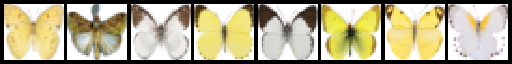

In [16]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample=Image.NEAREST)

## Scheduler


In [ ]:
from diffusers import DDPMScheduler

num_train_timesteps = 1000
noise_scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps)

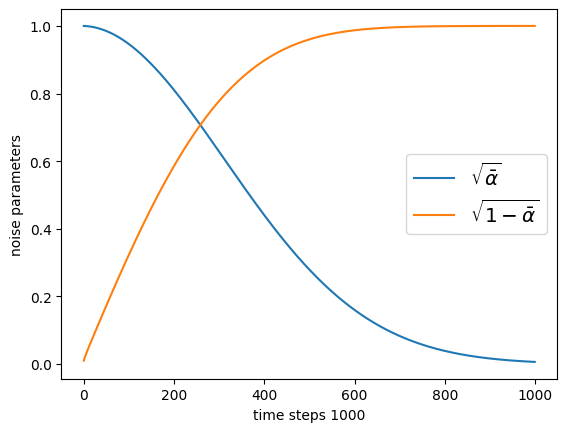

In [35]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"${\sqrt{1 - \bar{\alpha}}}$")
plt.xlabel(f'time steps {num_train_timesteps}')
plt.ylabel('noise parameters')
plt.legend(fontsize='x-large')

In [49]:
torch.randint(0, 999, (8,))

tensor([563, 647, 146, 376, 586, 668, 204,   8])

Noisy X shape torch.Size([8, 3, 32, 32])


/tmp/ipykernel_3028200/3004565193.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


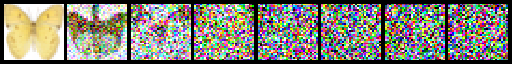

In [36]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 64, 64), resample=Image.NEAREST)

# Model


In [37]:
from diffusers import UNet2DModel

In [39]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        'DownBlock2D',
        'DownBlock2D',
        'AttnDownBlock2D',
        'AttnDownBlock2D',
    ),
    up_block_types=(
        'AttnUpBlock2D',
        'AttnUpBlock2D',
        'UpBlock2D',
        'UpBlock2D'
    )
)
model.to(device)

UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

In [40]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

# Model training loop


In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
losses = []
for epoch in range(30):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["images"].to(device)

        # sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # sample a ranfom timestep for each images
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

        # add noise to the clean images according to the noise magniture at each step
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # calculate loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss:{loss_last_epoch}")

/home/thankgod/2025/msc_project/.venv/lib/python3.10/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss:0.1523811616934836
Epoch:10, loss:0.1108942087739706
Epoch:15, loss:0.10059485863894224
Epoch:20, loss:0.08553719287738204
Epoch:25, loss:0.07834464777261019
Epoch:30, loss:0.07454203441739082


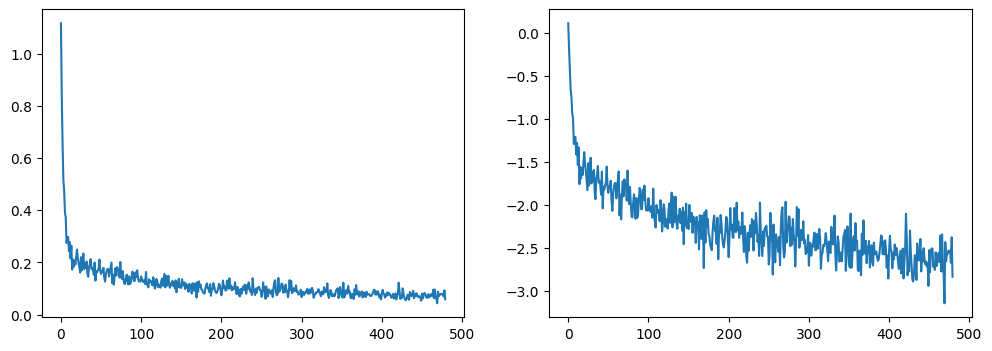

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

/tmp/ipykernel_3028200/3004565193.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


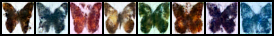

In [ ]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    # Get model pred
    with torch.no_grad():
        residual = model(sample, t).sample

    # Update sample with step
    sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample)

# Class-Conditioned Diffusion Model


In [ ]:
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([0, 7, 0, 5, 7, 8, 7, 8])


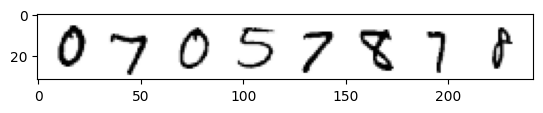

In [55]:
# Load the dataset
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

# Feed it into a dataloader (batch size 8 here just for demo)
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# View some examples
x, y = next(iter(train_dataloader))
print("Input shape:", x.shape)
print("Labels:", y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

In [ ]:
class ClassConditionedUnet(nn.Module):
    def __init__(self, num_classes=10, class_emb_size=4):
        super().__init__()

        # The embedding layer will map the class label to a vector of size class_emb_size
        self.class_emb = nn.Embedding(num_classes, class_emb_size)

        # Self.model is an unconditional UNet with extra input channels to accept the conditioning information
        self.model = UNet2DModel(
            sample_size = 28,
            in_channels=1 + class_emb_size, # Additional input channels for class cond.
            out_channels=1, # the number of output channels
            layers_per_block=2, # how many ResNet layer to use per Unet Block
            block_out_channels=(32, 64, 64),
            down_block_types=(
                "DownBlock2D", # a regular ResNet downsampling block
                "AttnDownBlock2D", # a ResNet downsampling block with spatial self-attention
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "AttnUpBlock2D", # a ResNet upsampling block with saptial self-attention
                "UpBlock2D", # a regular ResNet upsampling block
            )
        )

    # Our forward method can take the class label as an additional argument
    def forward(self, x, t, class_labels):
        # Shape of x:
        bs, ch, w, h = x.shape

        # class conditioning in right shape to add as additional input channels
        class_cond = self.class_emb(class_labels)
        class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1).expand(bs, class_cond.shape[1], w, h)
        # x is shape (bs, 1, 28, 28) and class_cond is now (bs, 4, 28, 28)

        # Net input is now x and class cond concatenated together along dimension 1
        net_input = torch.cat((x, class_cond), 1)

        # Feed this to the UNet alongside the timestep and return the prediction
        return self.model(net_input, t).sample

In [59]:
# Create a scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")

# Training loop (10 Epochs):


  0%|          | 0/469 [00:00<?, ?it/s]

100%|██████████| 469/469 [01:17<00:00,  6.03it/s]


Finished epoch 0. Average of the last 100 loss values: 0.053576


100%|██████████| 469/469 [01:18<00:00,  5.95it/s]


Finished epoch 1. Average of the last 100 loss values: 0.046629


...

Finished epoch 7. Average of the last 100 loss values: 0.040464


100%|██████████| 469/469 [01:19<00:00,  5.90it/s]


Finished epoch 8. Average of the last 100 loss values: 0.039358


100%|██████████| 469/469 [01:19<00:00,  5.92it/s]

Finished epoch 9. Average of the last 100 loss values: 0.039180


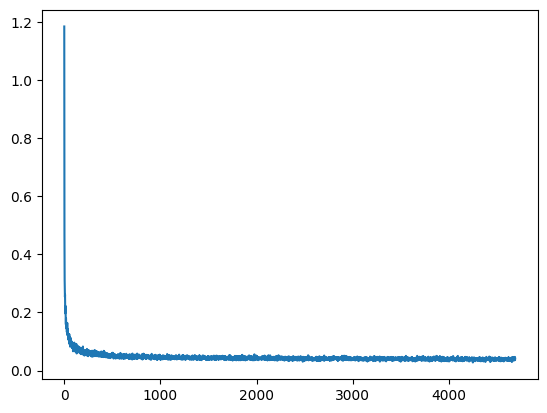

In [69]:
# Redefining the dataloader to set the batch size higher than the demo of 8
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# How many runs through the data should we do?
n_epochs = 10

# Our network
net = ClassConditionedUnet().to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):
    for x, y in tqdm(train_dataloader):

        # Get some data and prepare the corrupted version
        x = x.to(device) * 2 - 1  # Data on the GPU (mapped to (-1, 1))
        y = y.to(device)
        noise = torch.randn_like(x)
        timesteps = torch.randint(0, 999, (x.shape[0],)).long().to(device)
        noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

        # Get the model prediction
        pred = net(noisy_x, timesteps, y)  # Note that we pass in the labels y

        # Calculate the loss
        loss = loss_fn(pred, noise)  # How close is the output to the noise

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print out the average of the last 100 loss values to get an idea of progress:
    avg_loss = sum(losses[-100:]) / 100
    print(f"Finished epoch {epoch}. Average of the last 100 loss values: {avg_loss:05f}")

# View the loss curve
plt.plot(losses)

# Sampling some different digits:


1000it [00:28, 35.22it/s]


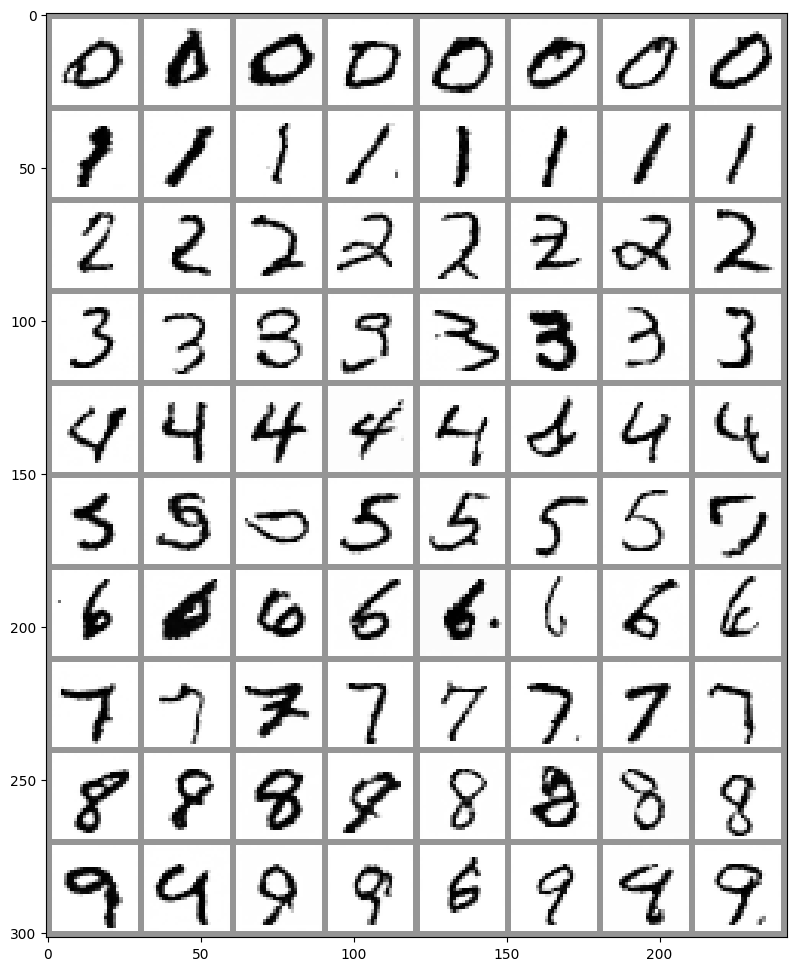

In [70]:
# Prepare random x to start from, plus some desired labels y
x = torch.randn(80, 1, 28, 28).to(device)
y = torch.tensor([[i] * 8 for i in range(10)]).flatten().to(device)

# Sampling loop
for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    # Get model pred
    with torch.no_grad():
        residual = net(x, t, y)  # Again, note that we pass in our labels y

    # Update sample with step
    x = noise_scheduler.step(residual, t, x).prev_sample

# Show the results
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0], cmap="Greys")